#  Phân tích dữ liệu giá phòng trọ sinh viên
## 1. Phát biểu bài toán  
Mục tiêu của bài toán là khảo sát dữ liệu giá phòng trọ sinh viên tại 3 thành phố Hà Nội, Đà Nẵng, Hồ Chí Minh nhằm xác định các đặc trưng quan trọng ảnh hưởng đến giá thuê phòng.  

Bài toán mô hình hoá đặt ra là dự đoán giá phòng: bài toán hồi quy (Regression)



## 2. Thu thập dữ liệu  
- **Nguồn dữ liệu**: Dữ liệu được crawl từ trang web đăng tin nhà trọ tại [Phongtro123.vn](https://phongtro123.com)  
- **Số lượng mẫu**: 1500 mẫu (500 cho mỗi thành phố)
- **Số lượng biến**:
  - Tiêu đề - Title
  - Giá phòng - Price (VNĐ/tháng) - Target Variable
  - Diện tích - Area (m²)
  - Địa điểm - Address (Thành phố nào)
  - Thời gian đăng - Time
  - Mô tả - Decription
  - Nổi bật - Highlights

### Cách thức thu thập  
Dữ liệu được thu thập bằng phương pháp **web scraping** sử dụng Python (Selenium).


## 3. Thống kê mô tả dữ liệu  


Import các thư viện cần thiết

In [427]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import re
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

### Xem trước 5 dòng của file raw_data

In [428]:
df = pd.read_csv('raw_data.csv')
df.head()

,Title,Price,Address,Time_Post,Area,Description,Highlights
0,80 BÀ TRIỆU - ĐẦY ĐỦ NỘI THẤT - GẦN CHỢ HÀ ĐÔNG,3.2 triệu/tháng,"Bà Triệu, Phường Hà Cầu, Quận Hà Đông, Hà Nội ...",Cập nhật: 3 tuần trước,20 m²,Thông tin mô tả\nHland Tower 119: Căn hộ dịch ...,"Đầy đủ nội thất, Có kệ bếp, Có máy lạnh, Có má..."
1,Studio Siêu Đẹp Ngõ 176 Đội Cấn. Vào ở luôn,8.7 triệu/tháng,"Phường Đội Cấn, Quận Ba Đình, Hà Nội - Xem b...",Cập nhật: 1 tháng trước,40 m²,Thông tin mô tả\nCăn studio Cao Cấp siêu đẹp s...,"Đầy đủ nội thất, Có kệ bếp, Có máy lạnh, Có má..."
2,24 CHỢ MỖ LAO - STUDIO FULL NỘI THẤT - GẦN PTI...,3.8 triệu/tháng,"Đường Mỗ Lao, Phường Mỗ Lao, Quận Hà Đông, Hà ...",Cập nhật: 2 ngày trước,24 m²,Thông tin mô tả\nHland Tower 124: Căn hộ dịch ...,"Đầy đủ nội thất, Có kệ bếp, Có máy lạnh, Có má..."
3,nhượng phòng view hồ tây lộng gió đầu tháng 10...,4 triệu/tháng,"229 Trích Sài, Phường Bưởi, Quận Tây Hồ, Hà Nộ...",Cập nhật: 6 tháng trước,40 m²,Thông tin mô tả\nBan công view hồ\nmáy giạt nó...,Không có
4,CĂN HỘ STUDIO TẠI DƯƠNG NỘI - FULL NỘI THẤT - ...,3.4 triệu/tháng,"Đường Tố Hữu, Phường Dương Nội, Quận Hà Đông, ...",Cập nhật: 3 tháng trước,22 m²,Thông tin mô tả\nHland Tower 141: Can hộ dịch ...,"Đầy đủ nội thất, Có kệ bếp, Có máy lạnh, Có má..."


Thông tin về các biến

In [429]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Title        1500 non-null   object
 1   Price        1500 non-null   object
 2   Address      1500 non-null   object
 3   Time_Post    1500 non-null   object
 4   Area         1500 non-null   object
 5   Description  1500 non-null   object
 6   Highlights   1500 non-null   object
dtypes: object(7)
memory usage: 82.2+ KB


In [430]:
df.describe()

,Title,Price,Address,Time_Post,Area,Description,Highlights
count,1500,1500,1500,1500,1500,1500,1500
unique,1489,99,1365,46,66,1497,210
top,[Cho thuê nhà C4] cuối ngõ 176 Nguyễn đình hoàn,3 triệu/tháng,"Yên Xá, Xã Tân Triều, Huyện Thanh Trì, Hà Nội ...",Cập nhật: 3 năm trước,25 m²,"Thông tin mô tả\nPhòng trọ 1PN + 1 WC/PT, diện...",Không có
freq,2,110,10,135,315,2,864


Số lượng dòng mang giá trị "Không có" trong cột highlights: 864 dòng
-> Mục tiêu tìm phần mô tả trong phần description để fill cho highlights

In [431]:
before_cleaning = (df["Highlights"] == "Không có").sum()
print(before_cleaning)

864


## 4. Làm sạch và chuẩn hoá dữ liệu

### 1. Làm sạch 

Xoá bỏ các hàng trùng lặp

In [432]:
# Làm sạch dữ liệu
df = df.dropna()  # Xóa các hàng có giá trị NaN
# xoá các dòng có title trùng lặp
df = df.drop_duplicates(subset=['Title'])  # Giữ lại hàng đầu tiên trong các hàng trùng lặp
# xoá các dòng có địa chỉ trùng lặp
df = df.drop_duplicates(subset=['Address'])  # Giữ lại hàng đầu tiên trong các hàng trùng lặp


df.describe()


,Title,Price,Address,Time_Post,Area,Description,Highlights
count,1359,1359,1359,1359,1359,1359,1359
unique,1359,95,1359,46,65,1357,202
top,"Phòng trọ 16m2 tại 541/17 Núi Thành, Phường Hò...",3 triệu/tháng,"541/17 Núi Thành, Phường Hòa Cường Nam, Quận H...",Cập nhật: 1 năm trước,25 m²,Thông tin mô tả\n- Full nội thất: Giường tầng ...,Không có
freq,1,97,1,120,273,2,785


##### Chuyển đổi giá thành kiểu số thực (đơn vị triệu)


In [433]:

# Hàm chuyển đổi giá trị
def convert_price(price):
    price = price.lower().replace(',', '.').strip()

    is_million = "triệu/tháng" in price
    is_vnd = "đồng/tháng" in price

    if not (is_million or is_vnd): 
        return None

    # Tìm chuỗi số (có thể chứa dấu '.' hoặc ',')
    match = re.search(r'[\d.,]+', price)
    if not match:
        return None  # Không tìm thấy số hợp lệ

    num_str = match.group()

    # Xử lý trường hợp phân tách hàng nghìn (nếu có nhiều dấu '.')
    if num_str.count('.') > 1:
        num_str = num_str.replace('.', '')  # Xóa toàn bộ dấu '.' (hàng nghìn)
    
    try:
        price_value = float(num_str) 
    except ValueError:
        return None  
    if is_vnd:
        price_value /= 1_000_000  

    return price_value


df["Price"] = df["Price"].astype(str).apply(convert_price)






##### Chuyển đổi thời gian đăng thành đơn vị tháng

In [434]:
def convert_to_month(text):
    if 'năm' in text:
        return int(text.split()[2]) * 12
    elif 'tháng' in text:
        return int(text.split()[2])
    elif 'tuần' or 'ngày' in text or 'giờ' in text or 'phút' in text:
        return 1
    return text

df["Time_Post"] = df["Time_Post"].astype(str).apply(convert_to_month)


##### Chuyển đổi cột diện tích thành kiểu số thực đơn vị mét vuông

In [435]:
# Hàm xử lý diện tích
def convert_area(area):
    return float(area.split()[0]) if isinstance(area, str) else area 
df["Area"] = df["Area"].astype(str).apply(convert_area)

#### Tách phần địa chỉ và tạo 2 cột City và District

In [436]:
# Hàm tách Quận/Huyện và Thành phố từ Address
def extract_district_city(address):
    district_match = re.search(r"(Quận|Huyện) [^,]+", address)
    city_match = re.findall(r", ([^,]+)$", address)
    
    district = district_match.group(0) if district_match else "Không rõ"
    city = city_match[0] if city_match else "Không rõ"
    
    return district, city

df[["District", "City"]] = df["Address"].apply(lambda x: pd.Series(extract_district_city(str(x))))
df = df.iloc[1:].reset_index(drop=True)

Xoá bỏ phần chuỗi dư thừa sau tên thành phố "- xem bản đồ"

In [437]:
df['City'] = df['City'].apply(lambda x: x.split(" - ")[0] if isinstance(x, str) else x)
df.head()

,Title,Price,Address,Time_Post,Area,Description,Highlights,District,City
0,Studio Siêu Đẹp Ngõ 176 Đội Cấn. Vào ở luôn,8.7,"Phường Đội Cấn, Quận Ba Đình, Hà Nội - Xem b...",1,40.0,Thông tin mô tả\nCăn studio Cao Cấp siêu đẹp s...,"Đầy đủ nội thất, Có kệ bếp, Có máy lạnh, Có má...",Quận Ba Đình,Hà Nội
1,24 CHỢ MỖ LAO - STUDIO FULL NỘI THẤT - GẦN PTI...,3.8,"Đường Mỗ Lao, Phường Mỗ Lao, Quận Hà Đông, Hà ...",1,24.0,Thông tin mô tả\nHland Tower 124: Căn hộ dịch ...,"Đầy đủ nội thất, Có kệ bếp, Có máy lạnh, Có má...",Quận Hà Đông,Hà Nội
2,nhượng phòng view hồ tây lộng gió đầu tháng 10...,4.0,"229 Trích Sài, Phường Bưởi, Quận Tây Hồ, Hà Nộ...",6,40.0,Thông tin mô tả\nBan công view hồ\nmáy giạt nó...,Không có,Quận Tây Hồ,Hà Nội
3,CĂN HỘ STUDIO TẠI DƯƠNG NỘI - FULL NỘI THẤT - ...,3.4,"Đường Tố Hữu, Phường Dương Nội, Quận Hà Đông, ...",3,22.0,Thông tin mô tả\nHland Tower 141: Can hộ dịch ...,"Đầy đủ nội thất, Có kệ bếp, Có máy lạnh, Có má...",Quận Hà Đông,Hà Nội
4,"Phòng trọ 3tr VSKK, bếp riêng tại Nhổn, gần ga...",3.0,"Ngách 80 Đường Xuân Phương, Phường Phương Canh...",1,30.0,Thông tin mô tả\nPhòng trọ cho thuê tại Tu hoà...,"Có kệ bếp, Có máy lạnh, Không chung chủ, Giờ g...",Quận Nam Từ Liêm,Hà Nội


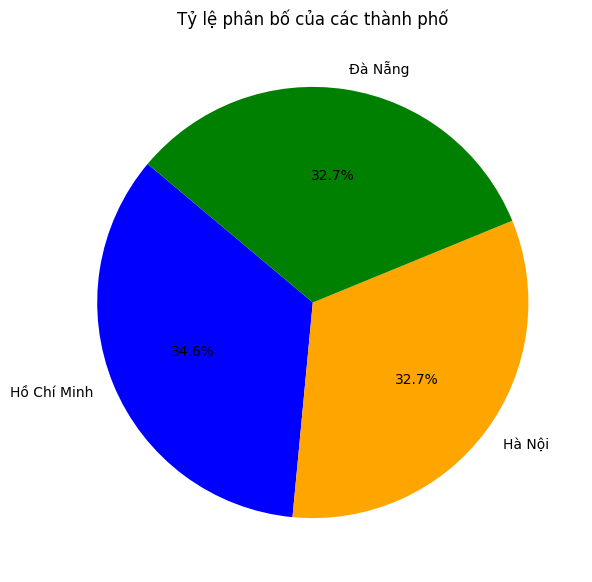

In [438]:


# Vẽ biểu đồ tròn
city_counts = df["City"].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(city_counts, labels=city_counts.index, autopct='%1.1f%%', startangle=140, colors=['blue', 'orange', 'green'])
plt.title("Tỷ lệ phân bố của các thành phố")
plt.show()


In [439]:
df.describe()

,Price,Time_Post,Area
count,1352.000000,1358.000000,1358.000000
mean,3.010456,7.863770,27.208100
std,1.608413,11.614789,19.692078
min,0.550000,1.000000,0.000000
25%,1.900000,1.000000,20.000000
50%,2.800000,1.000000,25.000000
75%,3.800000,11.000000,30.000000
max,28.000000,60.000000,350.000000


##### Trích các thông tin từ cột Desciption bổ sung cho cột highlights nếu bị trống dữ liệu


183


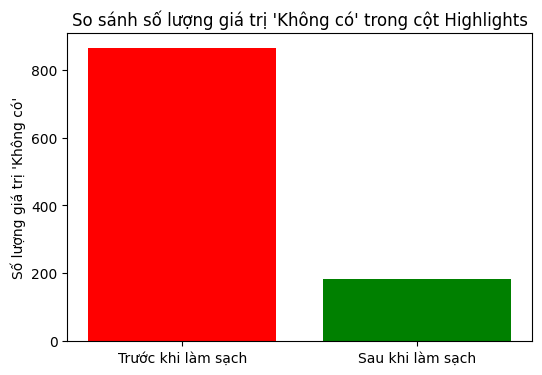

In [440]:


# Danh sách từ khóa để tìm kiếm (theo thông tin nổi bật trên web)
keywords = [
    "nội thất", "gác", "kệ bếp", "máy lạnh", "máy giặt", "tủ lạnh", "thang máy", 
    "chung chủ", "không chung chủ", "giờ giấc tự do", "bảo vệ 24/24", "hầm để xe"
]

def process_description(description):
    """Hàm xử lý cột mô tả: viết thường và lọc từ khóa"""
    description = description.lower()
    found_keywords = [word for word in keywords if word in description]
    
    # Nếu có "không chung chủ", loại bỏ "chung chủ"
    if "không chung chủ" in found_keywords and "chung chủ" in found_keywords:
        found_keywords.remove("chung chủ")
    if len(found_keywords) == 0:
        return None
    return ", ".join(found_keywords)

# Lọc ra các dòng có chứa "Không có" trong cột "Highlights"
df_filtered = df[df['Highlights'].str.contains("Không có", na=False)].copy()
df_removed = df[~df['Highlights'].str.contains("Không có", na=False)].copy()
df_removed['Highlights'] = df_removed["Highlights"].str.lower()
# Cập nhật cột "Highlights" trong df_filtered
df_filtered['Highlights'] = df_filtered['Description'].astype(str).apply(process_description)

# Gộp lại thành DataFrame hoàn chỉnh
df = pd.concat([df_filtered, df_removed]).reset_index(drop=True)

# Xử lý chuỗi rỗng trong "Highlights"
df['Highlights'] = df['Highlights'].fillna("")
df['Highlights'] = df['Highlights'].str.replace("có ", "", regex=False)
df['Highlights'] = df['Highlights'].str.replace("đầy đủ ", "", regex=False)

# Xóa các dòng có giá trị NaN trong "Highlights"
df = df.dropna(subset=['Highlights'])  # Xóa NaN trước

after_cleaning = (df["Highlights"].str.strip() == "").sum() 

print(after_cleaning)
# Vẽ biểu đồ so sánh
plt.figure(figsize=(6, 4))
plt.bar(["Trước khi làm sạch", "Sau khi làm sạch"], [before_cleaning, after_cleaning], color=["red", "green"])
plt.ylabel("Số lượng giá trị 'Không có'")
plt.title("So sánh số lượng giá trị 'Không có' trong cột Highlights")
plt.show()


Xoá bỏ các dòng có highlight trống sau khi đã thực hiện fill

In [441]:
df = df[df['Highlights'].str.strip() != ""]  # Xóa dòng có chuỗi rỗng hoặc toàn dấu cách
df.head()

,Title,Price,Address,Time_Post,Area,Description,Highlights,District,City
1,Cho thuê phòng full nội thất 401 xuân đỉnh,3.5,"401 xuân đỉnh Xuân Đỉnh, Phường Xuân Đỉnh, Quậ...",5,28.0,Thông tin mô tả\nCho thuê phòng 401 xuân đỉnh\...,"nội thất, kệ bếp, máy giặt, tủ lạnh",Quận Bắc Từ Liêm,Hà Nội
2,Ở ghép 1194 đường Láng đầu Cầu Giấy cạnh ĐH GT...,17.5,"11 Đường Láng, Phường Láng Thượng, Quận Đống...",5,25.0,Thông tin mô tả\nHomestay ở ghép nơi gắn kết t...,"máy giặt, tủ lạnh, không chung chủ",Quận Đống Đa,Hà Nội
3,CĂN HỘ GÁC XÉP THIẾT KẾ HIỆN ĐẠI - FULL NỘI TH...,3.5,"21 Đường Yên Xá, Xã Tân Triều, Huyện Thanh Trì...",5,25.0,Thông tin mô tả\nHland Tower 156: 21 Yên xá.\n...,"nội thất, máy giặt, tủ lạnh",Huyện Thanh Trì,Hà Nội
4,"CHO THUÊ PHÒNG MỸ ĐÌNH BAN CÔNG, PHÒNG THOÁNG ...",2.6,"Đường Mỹ Đình, Phường Mỹ Đình 1, Quận Nam Từ L...",5,15.0,Thông tin mô tả\nCHO THUÊ PHÒNG GIỜ GIẤC THOẢI...,máy giặt,Quận Nam Từ Liêm,Hà Nội
5,CHÍNH CHỦ CHO THUÊ CCMN KHÉP KÍN - ĐỐNG ĐA,4.6,"206 Đường Thịnh Quang, Phường Thịnh Quang, Qu...",5,19.0,Thông tin mô tả\nCHÍNH CHỦ CHO THUÊ CCMN KHÉP ...,"nội thất, máy giặt, tủ lạnh, thang máy, không ...",Quận Đống Đa,Hà Nội


##### Loại bỏ các outliner đối với các cột giá trị số thực


In [ ]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]


df_clean = remove_outliers_iqr(df, "Price")
df_clean = remove_outliers_iqr(df_clean, "Area")
df_clean.head()

,Title,Price,Address,Time_Post,Area,Description,Highlights,District,City
1,Cho thuê phòng full nội thất 401 xuân đỉnh,3.5,"401 xuân đỉnh Xuân Đỉnh, Phường Xuân Đỉnh, Quậ...",5,28.0,Thông tin mô tả\nCho thuê phòng 401 xuân đỉnh\...,"nội thất, kệ bếp, máy giặt, tủ lạnh",Quận Bắc Từ Liêm,Hà Nội
3,CĂN HỘ GÁC XÉP THIẾT KẾ HIỆN ĐẠI - FULL NỘI TH...,3.5,"21 Đường Yên Xá, Xã Tân Triều, Huyện Thanh Trì...",5,25.0,Thông tin mô tả\nHland Tower 156: 21 Yên xá.\n...,"nội thất, máy giặt, tủ lạnh",Huyện Thanh Trì,Hà Nội
4,"CHO THUÊ PHÒNG MỸ ĐÌNH BAN CÔNG, PHÒNG THOÁNG ...",2.6,"Đường Mỹ Đình, Phường Mỹ Đình 1, Quận Nam Từ L...",5,15.0,Thông tin mô tả\nCHO THUÊ PHÒNG GIỜ GIẤC THOẢI...,máy giặt,Quận Nam Từ Liêm,Hà Nội
5,CHÍNH CHỦ CHO THUÊ CCMN KHÉP KÍN - ĐỐNG ĐA,4.6,"206 Đường Thịnh Quang, Phường Thịnh Quang, Qu...",5,19.0,Thông tin mô tả\nCHÍNH CHỦ CHO THUÊ CCMN KHÉP ...,"nội thất, máy giặt, tủ lạnh, thang máy, không ...",Quận Đống Đa,Hà Nội
8,Chính chủ cho thuê siêu phẩm căn hộ mini tại K...,4.7,"55/58 Thanh Bình, Phường Mỗ Lao, Quận Hà Đông,...",1,38.0,"Thông tin mô tả\nNhà mới, phòng thoáng mát nhi...","gác, máy lạnh, máy giặt, tủ lạnh, thang máy",Quận Hà Đông,Hà Nội


In [466]:
df_clean.describe()

,Price,Time_Post,Area,District_encode,City_encode
count,1056.000000,1056.000000,1056.000000,1056.000000,1056.000000
mean,3.125963,7.051136,24.509091,3.125963,3.125963
std,1.209670,11.197208,6.716916,0.696973,0.547192
min,0.750000,1.000000,8.000000,1.200000,2.267940
25%,2.200000,1.000000,20.000000,2.486842,2.267940
50%,3.000000,1.000000,25.000000,3.357500,3.378476
75%,3.900000,6.000000,30.000000,3.685897,3.555950
max,6.700000,60.000000,45.000000,4.638462,3.555950


##### Loại bỏ các phòng diện KTX, Sleepbox


In [444]:

df_clean = df_clean[~df_clean["Title"].str.contains("ký túc xá|sleepbox|ktx", case=False, na=False)]
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1056 entries, 1 to 1357
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Title        1056 non-null   object 
 1   Price        1056 non-null   float64
 2   Address      1056 non-null   object 
 3   Time_Post    1056 non-null   int64  
 4   Area         1056 non-null   float64
 5   Description  1056 non-null   object 
 6   Highlights   1056 non-null   object 
 7   District     1056 non-null   object 
 8   City         1056 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 82.5+ KB


##### So sánh về phân bố dữ liệu

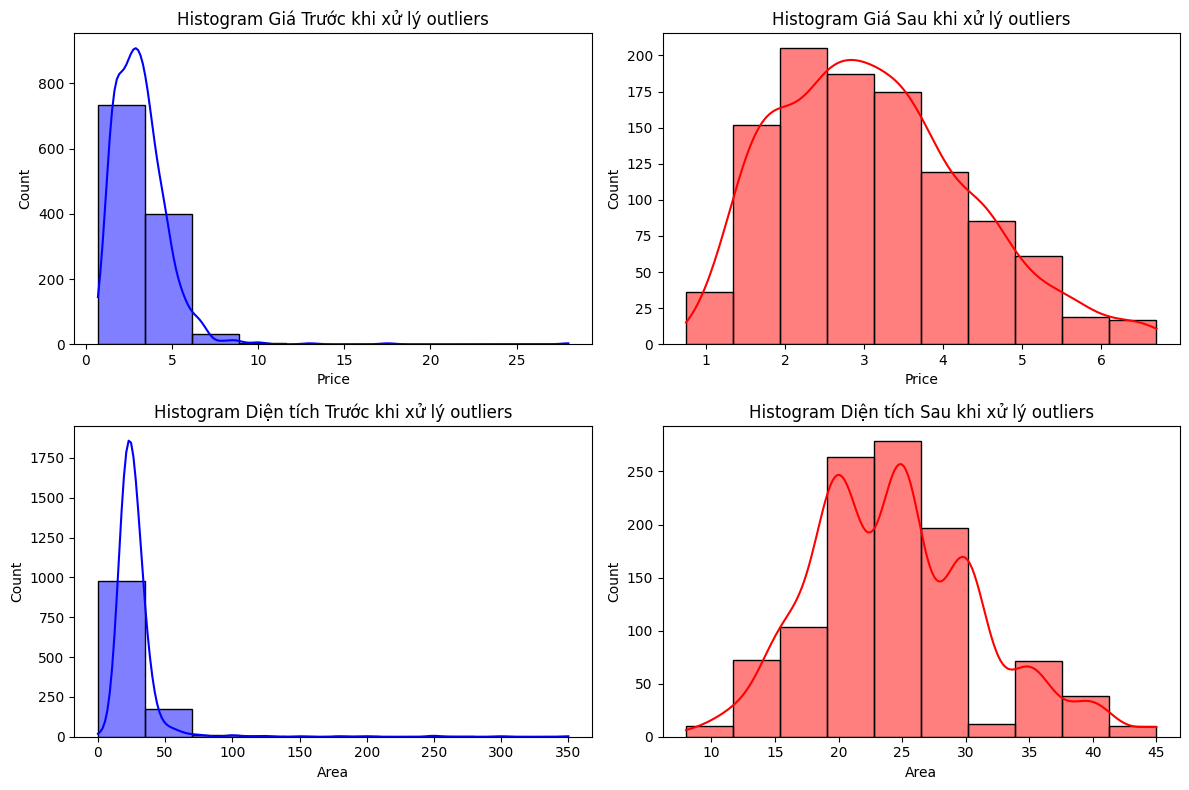

In [ ]:


fig, axes = plt.subplots(2, 2, figsize=(12, 8)) 

# Histogram trước khi xử lý outliers - Price
sns.histplot(df["Price"], bins=10, kde=True, ax=axes[0, 0], color='blue')
axes[0, 0].set_title("Histogram Giá Trước khi xử lý outliers")

# Histogram sau khi xử lý outliers - Price
sns.histplot(df_clean["Price"], bins=10, kde=True, ax=axes[0, 1], color='red')
axes[0, 1].set_title("Histogram Giá Sau khi xử lý outliers")

# Histogram trước khi xử lý outliers - Area
sns.histplot(df["Area"], bins=10, kde=True, ax=axes[1, 0], color='blue')
axes[1, 0].set_title("Histogram Diện tích Trước khi xử lý outliers")

# Histogram sau khi xử lý outliers - Area
sns.histplot(df_clean["Area"], bins=10, kde=True, ax=axes[1, 1], color='red')
axes[1, 1].set_title("Histogram Diện tích Sau khi xử lý outliers")

plt.tight_layout()
plt.show()


#### Mã hoá biến danh mục

1. Mã hoá biến District và City bằng giá trung bình tại địa điểm đó (Target encoding)
2. One-hot encoding cho các giá trị trong cột Highlights

In [446]:


df_clean["District_encode"] = df_clean.groupby("District")["Price"].transform("mean")

df_clean["City_encode"] = df_clean.groupby("City")['Price'].transform("mean")
# One-Hot Encoding cho Highlights (nhiều giá trị)
df_highlights = df_clean["Highlights"].str.get_dummies(sep=", ")  # Chuyển thành cột nhị phân

# Ghép lại DataFrame
df_encoded = pd.concat([df_clean.drop(columns=["Highlights"]), df_highlights], axis=1)
# Xóa cột "Address" và "Description"
df_encoded = df_encoded.drop(columns=["Address", "Description"])

# Xem lại dữ liệu sau khi xóa cột
df_encoded.head()

df_encoded.to_csv('clean_data.csv', encoding="utf-8", index=False)


In [447]:
df = pd.read_csv("clean_data.csv")
df.head()

,Title,Price,Time_Post,Area,District,City,District_encode,City_encode,bảo vệ 24/24,chung chủ,giờ giấc tự do,gác,hầm để xe,không chung chủ,kệ bếp,máy giặt,máy lạnh,nội thất,thang máy,tủ lạnh
0,Cho thuê phòng full nội thất 401 xuân đỉnh,3.5,5,28.0,Quận Bắc Từ Liêm,Hà Nội,3.217647,3.378476,0,0,0,0,0,0,1,1,0,1,0,1
1,CĂN HỘ GÁC XÉP THIẾT KẾ HIỆN ĐẠI - FULL NỘI TH...,3.5,5,25.0,Huyện Thanh Trì,Hà Nội,3.560000,3.378476,0,0,0,0,0,0,0,1,0,1,0,1
2,"CHO THUÊ PHÒNG MỸ ĐÌNH BAN CÔNG, PHÒNG THOÁNG ...",2.6,5,15.0,Quận Nam Từ Liêm,Hà Nội,3.374468,3.378476,0,0,0,0,0,0,0,1,0,0,0,0
3,CHÍNH CHỦ CHO THUÊ CCMN KHÉP KÍN - ĐỐNG ĐA,4.6,5,19.0,Quận Đống Đa,Hà Nội,3.492647,3.378476,0,0,0,0,0,1,0,1,0,1,1,1
4,Chính chủ cho thuê siêu phẩm căn hộ mini tại K...,4.7,1,38.0,Quận Hà Đông,Hà Nội,3.387805,3.378476,0,0,0,1,0,0,0,1,1,0,1,1


#### 5. Đánh giá hệ số tương quan giữa các biến đối với biến Price

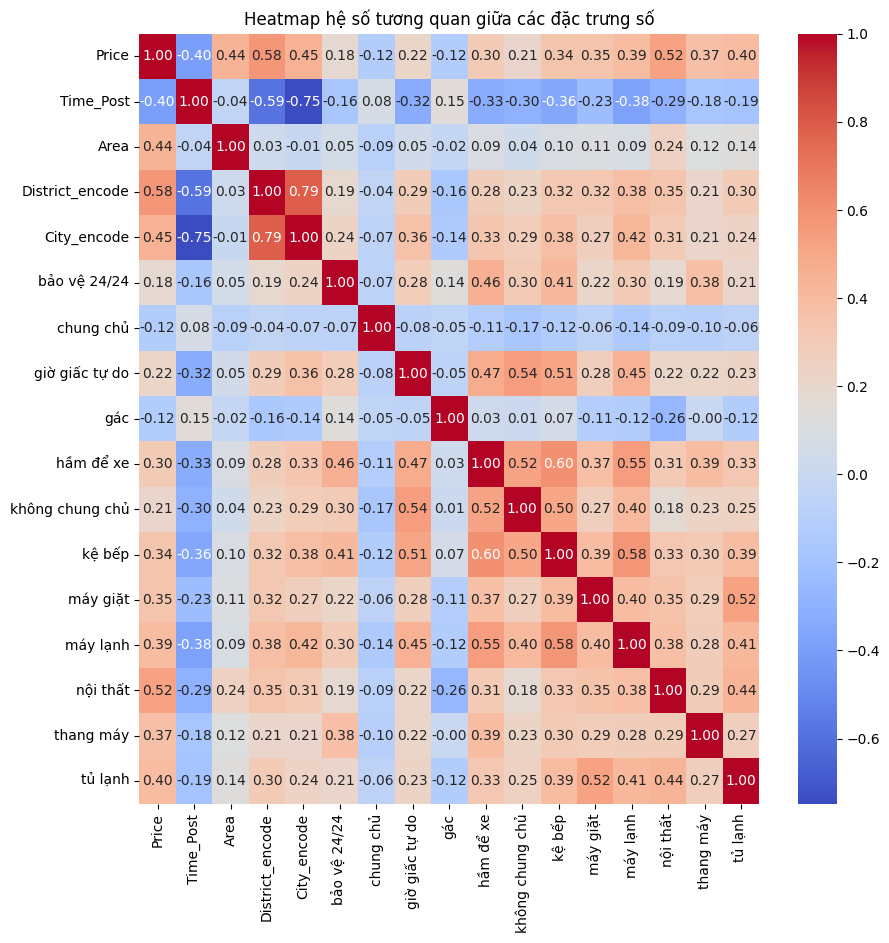

In [448]:


# Chỉ chọn các cột số để tính tương quan
num_cols = df.select_dtypes(include=['number'])

# Vẽ heatmap tương quan
plt.figure(figsize=(10, 10))
sns.heatmap(num_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap hệ số tương quan giữa các đặc trưng số")
plt.show()



In [449]:

num_cols = df.select_dtypes("number")

corr_matrix = num_cols.corr()["Price"].sort_values(ascending=False)
print(corr_matrix)



Price              1.000000
District_encode    0.576168
nội thất           0.522714
City_encode        0.452348
Area               0.444833
tủ lạnh            0.397661
máy lạnh           0.389685
thang máy          0.366518
máy giặt           0.346989
kệ bếp             0.338545
hầm để xe          0.301388
giờ giấc tự do     0.221067
không chung chủ    0.210486
bảo vệ 24/24       0.182676
chung chủ         -0.115221
gác               -0.121555
Time_Post         -0.396847
Name: Price, dtype: float64


Có thể thấy biến target price phụ thuộc tương đối đối với các đặt trưng District_encode, nội thất, city_encode và area (>0.4) và phụ thuộc nhẹ vào các đặc trưng: tủ lạnh, máy lạnh, máy giặt, kệ bếp và hầm để xe..

Đặc trưng chung chủ và gác có hệ số tương quan âm đối với price... làm giảm giá tiền

Dựa vào heatmap có thể thấy district_encode và city_encode phụ thuộc mạnh vào nhau (0.79). Cân nhắc lựa chọn 1 trong 2
Các feature có thể lựa chọn là Area, nội thất (có hay không), Tủ lạnh(có hay không), (Thành phố)

### Trực quan hoá mối quan hệ giữa các biến


##### Scatter plot giữa biến giá và diện tích

Có thể thấy xu hướng tăng giá khi tăng diện tích, nhưng không tuyến tính rõ ràng, có sự phân tán ở các mức diện tích cao. Cho thấy giá còn phụ thuộc vào các yếu tố khác 

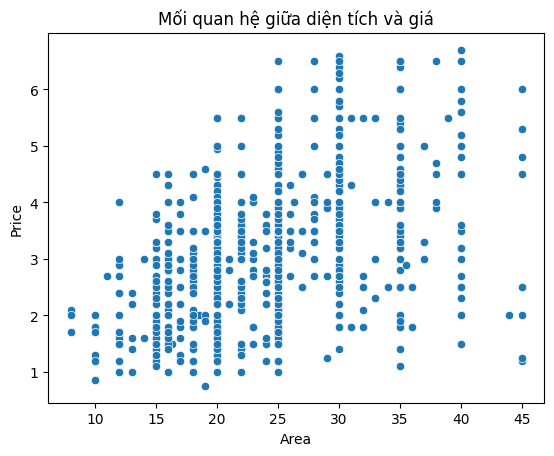

In [450]:
sns.scatterplot(x="Area", y="Price", data=df)
plt.title("Mối quan hệ giữa diện tích và giá")
plt.show()


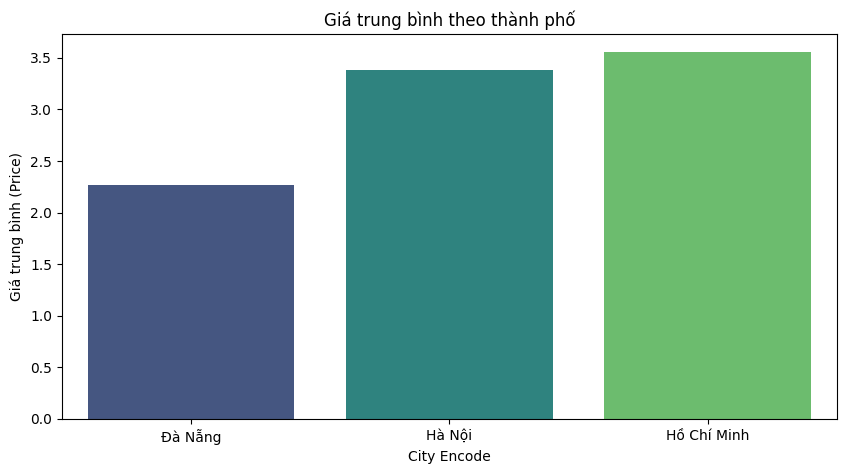

In [451]:


plt.figure(figsize=(10, 5))
city_avg_price = df.groupby("City")["Price"].mean().sort_values()
sns.barplot(x=city_avg_price.index, y=city_avg_price.values, hue=city_avg_price.index, palette="viridis", legend=False)

plt.title("Giá trung bình theo thành phố")
plt.xlabel("City Encode")
plt.ylabel("Giá trung bình (Price)")
plt.show()


Giá phòng trọ trung bình ở HCM nhỉnh hơn Hà Nội và Đà Nẵng. Giá trọ trung bình ở Đà Nẵng thấp nhất trong 3 thành phố

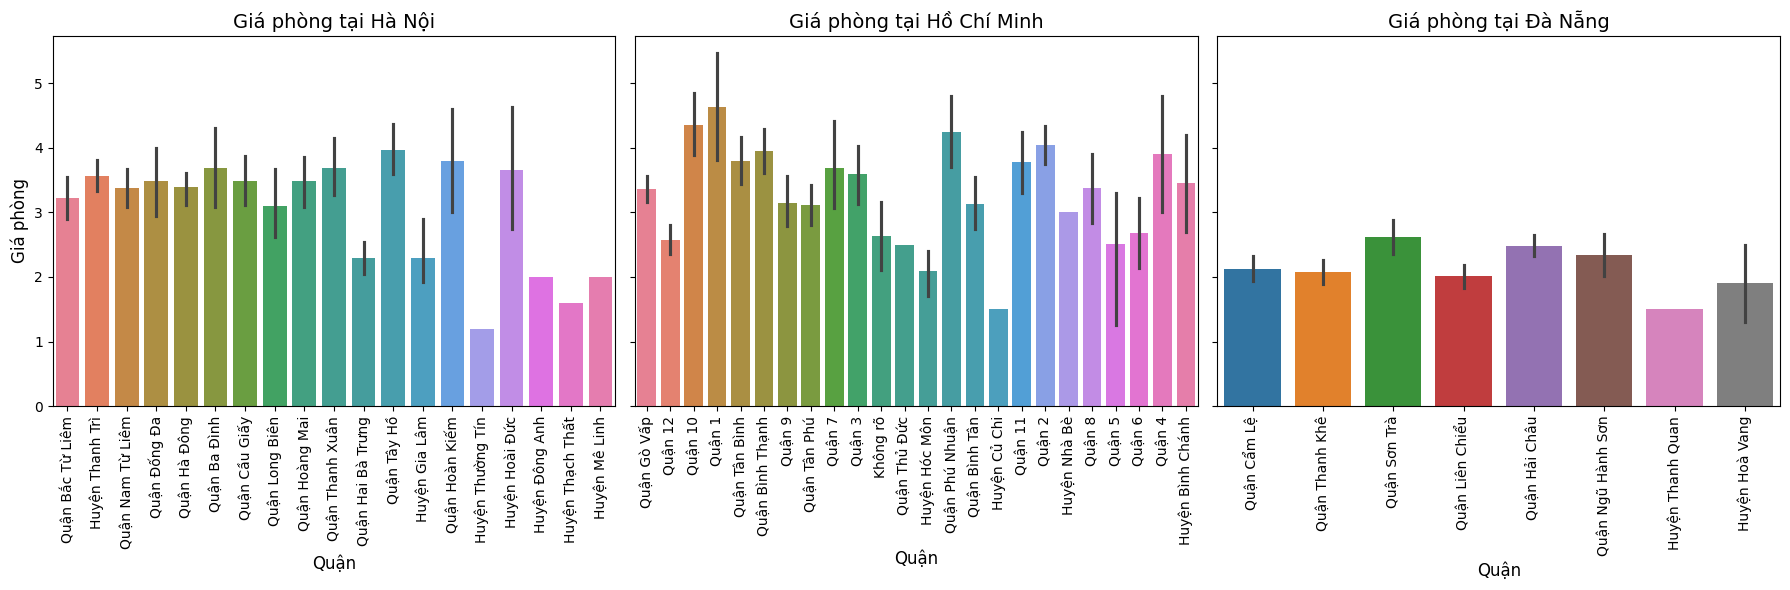

In [452]:

cities = df['City'].unique()


fig, axes = plt.subplots(1, len(cities), figsize=(18, 6), sharey=True)


for i, city in enumerate(cities):
    # Lọc dữ liệu cho từng thành phố
    city_data = df[df['City'] == city]
    sns.barplot(x="District", y="Price", data=city_data, ax=axes[i], hue= "District")
    
    axes[i].set_title(f"Giá phòng tại {city}", fontsize=14)
    axes[i].set_xlabel("Quận", fontsize=12)
    axes[i].set_ylabel("Giá phòng", fontsize=12)
    
    axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()



Giảm chiều dữ liệu để trực quan hoá bằng t-SNE

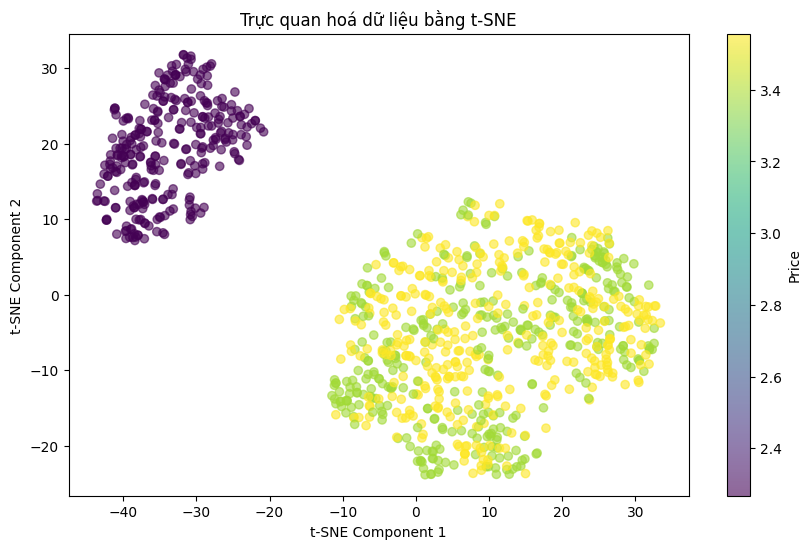

In [453]:


df_tnse = df.drop(columns=['Title', 'District', 'City', 'Time_Post'])

# # chuẩn hoá
scaler = StandardScaler()
numerical_cols = ['Price', 'Area', 'District_encode', 'City_encode']
df_tnse[numerical_cols] = scaler.fit_transform(df[numerical_cols])


# giảm chiều xuống 2
tsne = TSNE(n_components=2, perplexity=50, random_state=42)
X_embedded = tsne.fit_transform(df_tnse)


plt.figure(figsize=(10, 6))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=df["City_encode"], alpha=0.6, cmap='viridis')
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("Trực quan hoá dữ liệu bằng t-SNE")
plt.colorbar(label="Price")
plt.show()



##### Có sự phân cụm thành 2 cụm rõ rệt
Cụm bên trái (màu tím đậm) có giá trị City_encode thấp hơn. Điều này phù hợp với thành phố có giá trung bình thấp nhất (2.26).
Cụm bên phải (màu xanh-lá và vàng) có City_encode cao hơn, phù hợp với các thành phố có giá trung bình cao hơn (3.37 và 3.55).



Ảnh hưởng của giá trung bình (City_encode):

Cụm bên trái có giá trị thấp hơn và có sự tập trung cao (các điểm gần nhau). Điều này cho thấy giá ở thành phố này khá ổn định, không có sự chênh lệch lớn.
Cụm bên phải có sự phân tán lớn hơn, điều này có thể do giá ở hai thành phố có City_encode cao hơn có sự biến động mạnh.


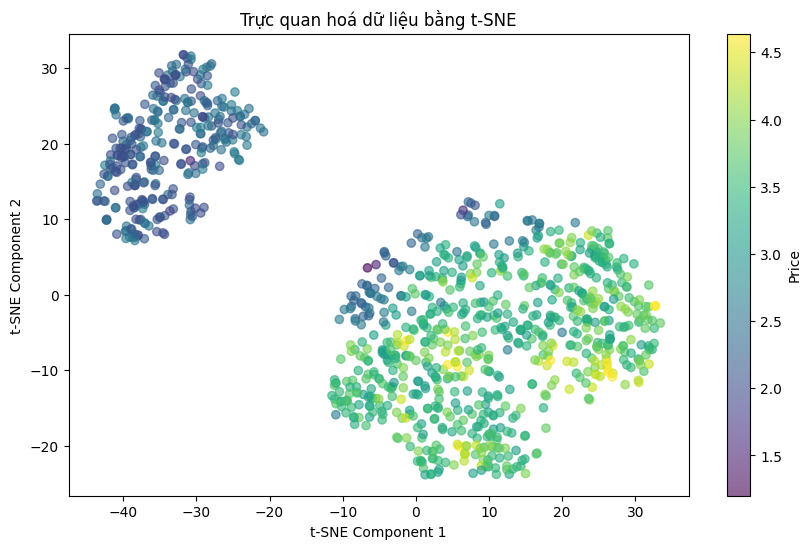

In [454]:


df_tnse = df.drop(columns=['Title', 'District', 'City', 'Time_Post'])

# # chuẩn hoá
scaler = StandardScaler()
numerical_cols = ['Price', 'Area', 'District_encode' , 'City_encode']
df_tnse[numerical_cols] = scaler.fit_transform(df[numerical_cols])


# giảm chiều xuống 2
tsne = TSNE(n_components=2, perplexity=50, random_state=42)
X_embedded = tsne.fit_transform(df_tnse)


plt.figure(figsize=(10, 6))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=df["District_encode"], alpha=0.6, cmap='viridis')
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("Trực quan hoá dữ liệu bằng t-SNE")
plt.colorbar(label="Price")
plt.show()


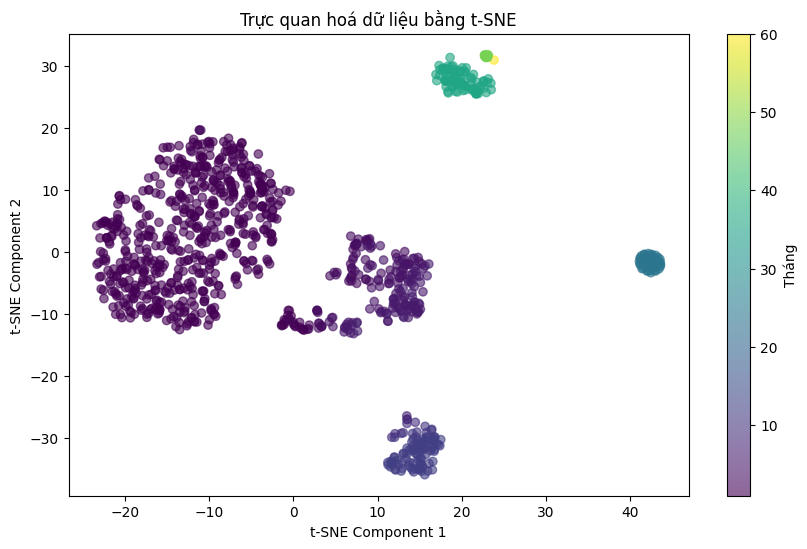

In [455]:

df_tnse = df.drop(columns=['Title', 'District', 'City'])

# # chuẩn hoá
scaler = StandardScaler()
numerical_cols = ['Price', 'Area', 'District_encode', 'City_encode']
df_tnse[numerical_cols] = scaler.fit_transform(df[numerical_cols])


# giảm chiều xuống 2
tsne = TSNE(n_components=2, perplexity=50, random_state=42)
X_embedded = tsne.fit_transform(df_tnse)


plt.figure(figsize=(10, 6))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=df["Time_Post"], alpha=0.6, cmap='viridis')
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("Trực quan hoá dữ liệu bằng t-SNE")
plt.colorbar(label="Tháng")
plt.show()


* Nếu thêm Time_post thì dữ liệu có thể phân thành 5 cụm rõ ràng
* Các điểm dữ liệu được nhóm thành 5 cụm theo năm, cho thấy rằng yếu tố thời gian đăng bài (Time_post) có ảnh hưởng lớn đến cách dữ liệu được phân cụm

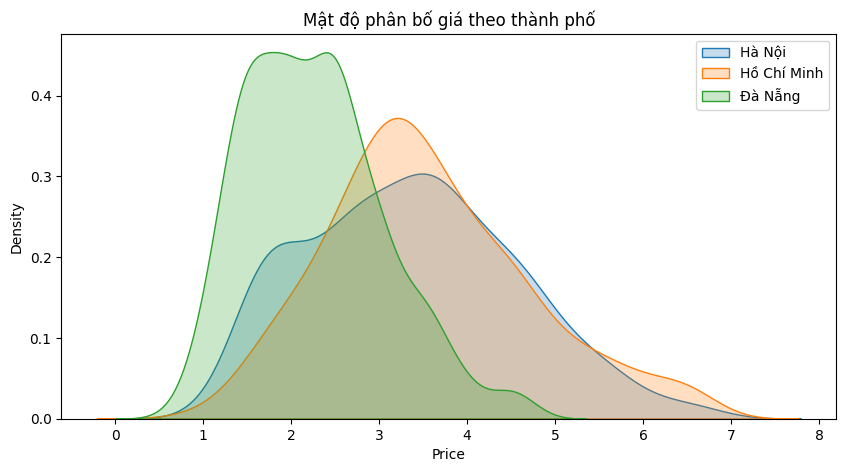

In [456]:
plt.figure(figsize=(10, 5))
for city in df["City"].unique():
    subset = df[df["City"] == city]
    sns.kdeplot(subset["Price"], label=city, fill=True)  # Thay shade=True bằng fill=True
plt.legend()
plt.title("Mật độ phân bố giá theo thành phố")
plt.show()


Đà Nẵng (City_encode ≈ 2.27, màu xanh lá): Có xu hướng tập trung ở khoảng giá từ 1.5 đến 3, cho thấy giá trung bình ở đây thấp hơn so với Hà Nội và TP HCM. Chỉ có một số ít dữ liệu rải rác ở mức giá cao hơn (quanh 4).

Hà Nội & TP HCM (City_encode ≈ 3.38 và 3.56, màu xanh dương & cam): Phân bố rộng hơn, tập trung nhiều trong khoảng 3 - 5 triệu, và có một số ít dữ liệu ở mức trên 6 triệu. Điều này cho thấy mức giá tại hai thành phố này có xu hướng cao hơn so với Đà Nẵng.

Mức giá từ 2 đến 4 triệu là phổ biến ở cả ba thành phố, thể hiện một khoảng giá chung mà nhiều sản phẩm hoặc dịch vụ có thể có mặt trên cả ba địa phương.

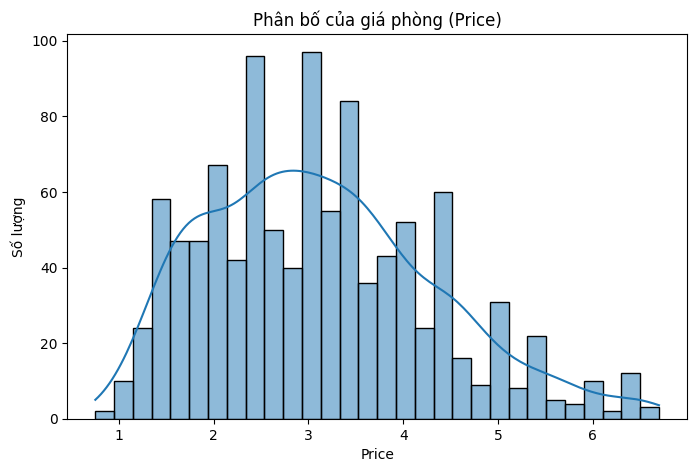

In [457]:

plt.figure(figsize=(8, 5))
sns.histplot(df["Price"], bins=30, kde=True)
plt.title("Phân bố của giá phòng (Price)")
plt.xlabel("Price")
plt.ylabel("Số lượng")
plt.show()

Chủ yếu là giá tầm trung từ 2-4 triệu 

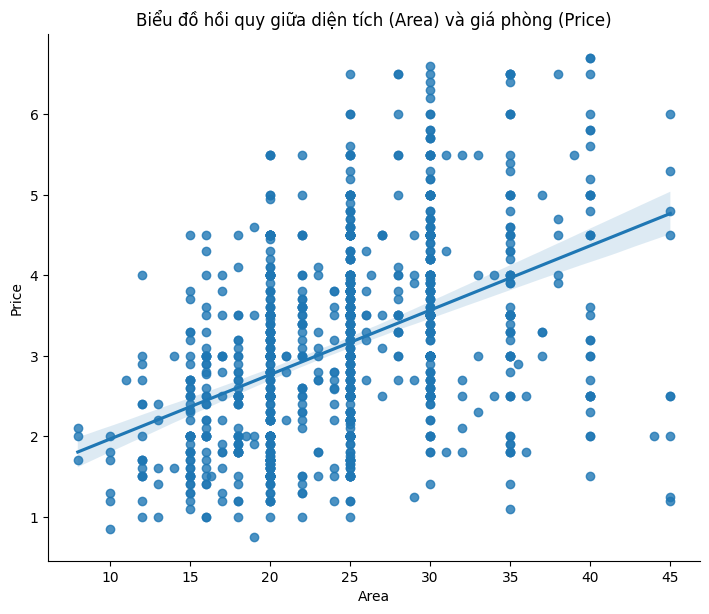

In [458]:

sns.lmplot(x="Area", y="Price", data=df, height=6, aspect=1.2)
plt.title("Biểu đồ hồi quy giữa diện tích (Area) và giá phòng (Price)")
plt.show()

Từ biểu đồ Lmplot cho thấy giá nhà có sự tuyến tính theo area nhưng vẫn có sự phân tán, chứng tỏ giá nhà còn bị ảnh hưởng bởi các yếu tố khác

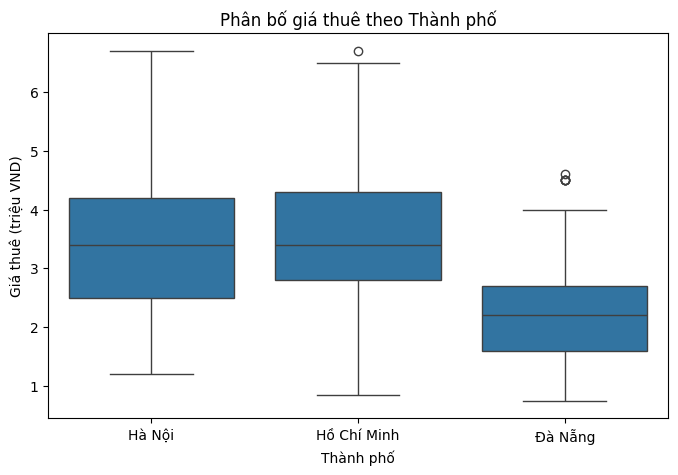

In [459]:

plt.figure(figsize=(8, 5))
sns.boxplot(x="City", y="Price", data=df)
plt.title("Phân bố giá thuê theo Thành phố")
plt.ylabel("Giá thuê (triệu VND)")
plt.xlabel("Thành phố")

plt.show()



Hà Nội có mức giá thuê ổn định hơn trong khi ở HCM thì bị phân tán
Đà Nẵng có mức phân bố thấp hơn, vẫn có 1 số phòng trọ trên 4tr nhưng số lượng ít 

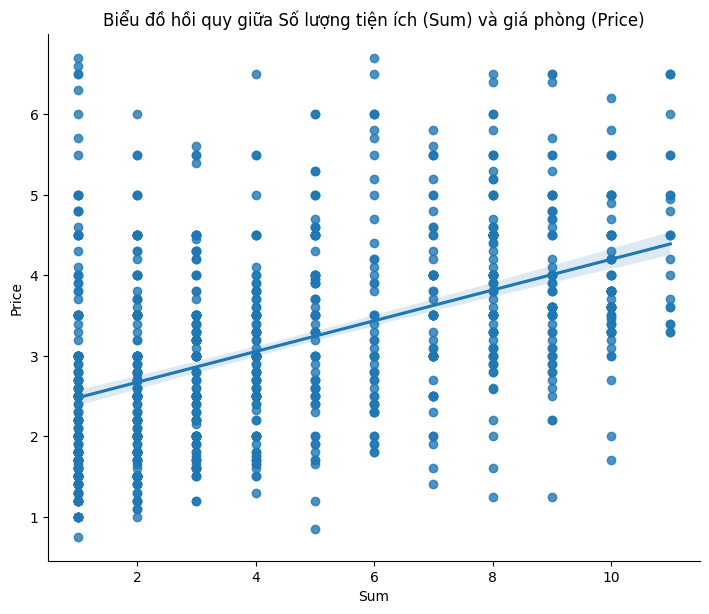

In [465]:
keywords = [
     "nội thất","gác", "kệ bếp", "máy lạnh", "máy giặt", "tủ lạnh", "thang máy", 
    "chung chủ", "không chung chủ", "giờ giấc tự do", "bảo vệ 24/24", "hầm để xe"
]
df['Sum'] = (df[keywords] == 1).sum(axis=1)

sns.lmplot(x="Sum", y="Price", data=df, height=6, aspect=1.2)
plt.title("Biểu đồ hồi quy giữa Số lượng tiện ích (Sum) và giá phòng (Price)")
plt.show()

Có thể thấy là số lượng tiện ích càng nhiều thì số tiền phòng càng tăng nhưng vẫn còn phân tán, ví dụ có 1 tiện ích thì nó vẫn còn tâp trung ở các mức giá từ 1->3 triệu và rải rác ở các khoảng giá khác. Có thể tiện ích ở đây là nội thất đầy đủ, là tiện ích có ảnh hưởng mạnh nhất

In [462]:
# Đếm số lượng phòng trọ trong mỗi quận/huyện
district_density = df["District"].value_counts()

# Chuẩn hóa giá trị để thể hiện tỷ lệ so với toàn bộ dữ liệu
df["Rental_Density"] = df["District"].map(district_density) / len(df)

# Kiểm tra lại dữ liệu
print(df[["District", "Rental_Density"]].head())

           District  Rental_Density
0  Quận Bắc Từ Liêm        0.032197
1   Huyện Thanh Trì        0.018939
2  Quận Nam Từ Liêm        0.044508
3      Quận Đống Đa        0.032197
4      Quận Hà Đông        0.038826


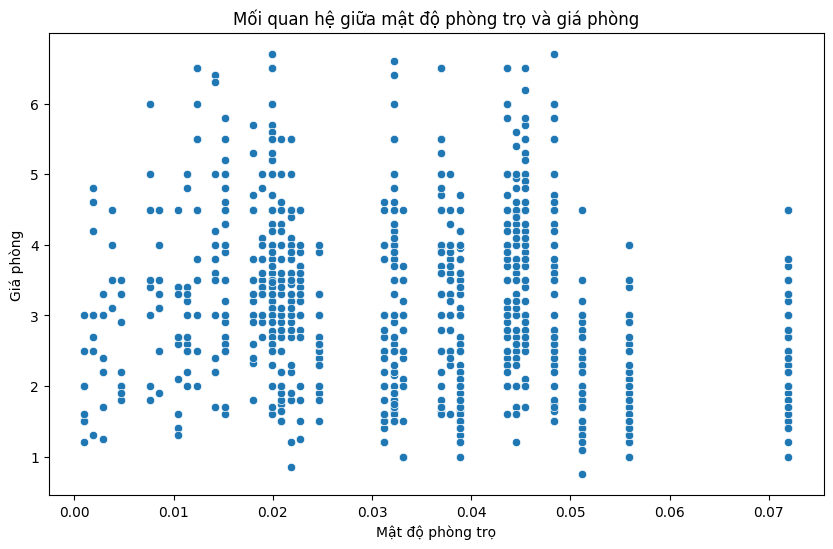

In [463]:


# Vẽ biểu đồ để kiểm tra mối quan hệ giữa Mật độ phòng trọ và Giá
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Rental_Density", y="Price")
plt.xlabel("Mật độ phòng trọ")
plt.ylabel("Giá phòng")
plt.title("Mối quan hệ giữa mật độ phòng trọ và giá phòng")
plt.show()


Không có xu hướng rõ ràng, có vẻ mật độ phòng trọ không phải yếu tố ảnh hưởng đến giá phòng

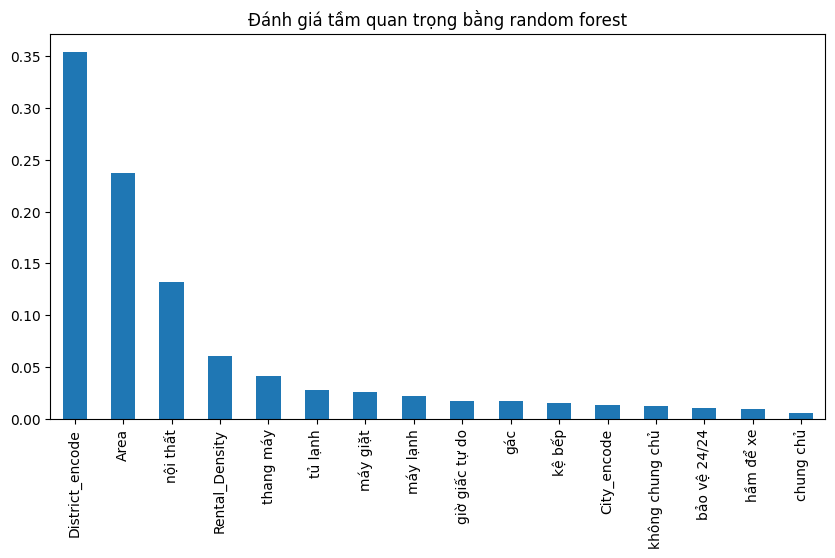

In [464]:

X = df.drop(columns=["Price", "Title", "District", "City","Time_Post", "Sum"])
y = df["Price"]

# Chia tập train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Huấn luyện mô hình Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

#Đánh giá tầm quan trọng của feature bằng Random Forest
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importances.sort_values(ascending=False).plot(kind='bar', figsize=(10, 5), title='Đánh giá tầm quan trọng bằng random forest')
plt.show()




### 6. Kết luận
Dựa trên phân tích dữ liệu, bài toán dự đoán giá phòng trọ là khả thi về mặt dữ liệu. Biến mục tiêu (giá phòng) có sự phụ thuộc nhất định vào một số đặc trưng quan trọng như diện tích, vị trí địa lý (quận/huyện, thành phố), tiện ích nội thất, Những đặc trưng này đều có ảnh hưởng trực tiếp đến giá phòng, cho phép xây dựng mô hình dự đoán hợp lý.


Các đặc trưng có thể sử dụng để xây dựng mô hình dự đoán: 
- Diện tích
- Thành phố
- Quận
- Nội thất 




### 7. Tài liệu tham khảo
* https://phamdinhkhanh.github.io/2019/01/07/Ky_thuat_feature_engineering.html
* https://www.yourdatateacher.com/2021/10/11/feature-selection-with-random-forest/